## Ejecutar este notebook en Google Colab

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_IV_05_THD_y_espectro.ipynb)

# Notebook V.2 — Curvas $N(A)$ y lectura geométrica de ciclos límite

Este notebook construye funciones descriptivas $N(A)$ para no linealidades clásicas
y muestra la lectura geométrica del criterio aproximado

$$
1 + G(j\omega)N(A) = 0.
$$

La idea es visualizar cómo una no linealidad puede convertirse en una familia
de ganancias armónicas parametrizadas por la amplitud.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

M = 1.5
K = 1.0
E = 1.0
D = 0.8
alpha = 1.0
beta = 0.12

Avals = np.linspace(0.2, 5.0, 500)

In [2]:
def N_relay(A, M):
    return 4*M/(np.pi*A)

def N_saturation(A, K, E):
    A = np.asarray(A)
    out = np.empty_like(A, dtype=float)
    mask = A <= E
    out[mask] = K
    z = E/A[~mask]
    out[~mask] = (2*K/np.pi)*(np.arcsin(z) + z*np.sqrt(1-z**2))
    return out

def N_dead_zone(A, K, D):
    A = np.asarray(A)
    out = np.empty_like(A, dtype=float)
    mask = A <= D
    out[mask] = 0.0
    z = D/A[~mask]
    out[~mask] = (2*K/np.pi)*(np.pi/2 - np.arcsin(z) - z*np.sqrt(1-z**2))
    return out

def N_cubic(A, alpha, beta):
    return alpha + 0.75*beta*A**2

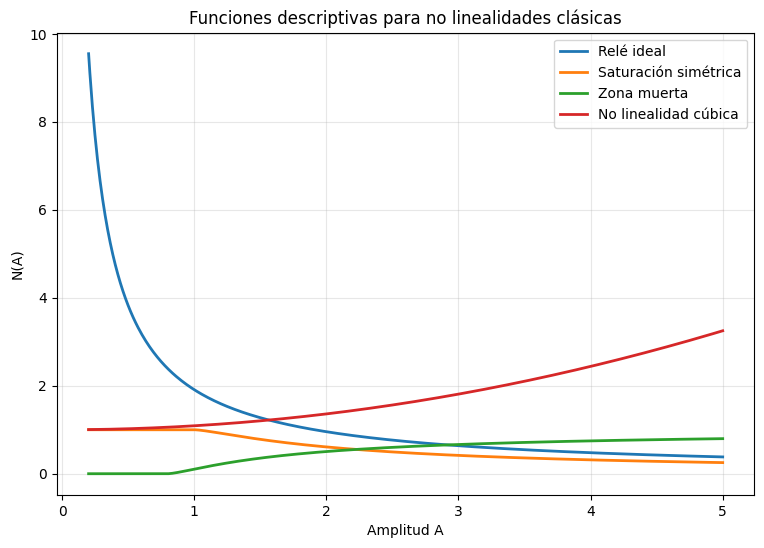

In [3]:
Nrelay = N_relay(Avals, M)
Nsat = N_saturation(Avals, K, E)
Ndead = N_dead_zone(Avals, K, D)
Ncubic = N_cubic(Avals, alpha, beta)

plt.figure(figsize=(9,6))
plt.plot(Avals, Nrelay, label="Relé ideal", linewidth=2)
plt.plot(Avals, Nsat, label="Saturación simétrica", linewidth=2)
plt.plot(Avals, Ndead, label="Zona muerta", linewidth=2)
plt.plot(Avals, Ncubic, label="No linealidad cúbica", linewidth=2)
plt.xlabel("Amplitud A")
plt.ylabel("N(A)")
plt.title("Funciones descriptivas para no linealidades clásicas")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Planta lineal de ejemplo

Usaremos una planta con retardo:

$$
G(s)=\frac{K_g e^{-sL}}{s+a}.
$$

La condición de fase puede resolverse numéricamente, y luego la condición de magnitud
fija la amplitud candidata.

In [4]:
K_g = 3.0
a = 1.0
L = 1.2

def G_of_jw(w, K_g=K_g, a=a, L=L):
    return K_g*np.exp(-1j*w*L)/(a + 1j*w)

wvals = np.linspace(0.01, 8.0, 1200)
Gjw = G_of_jw(wvals)

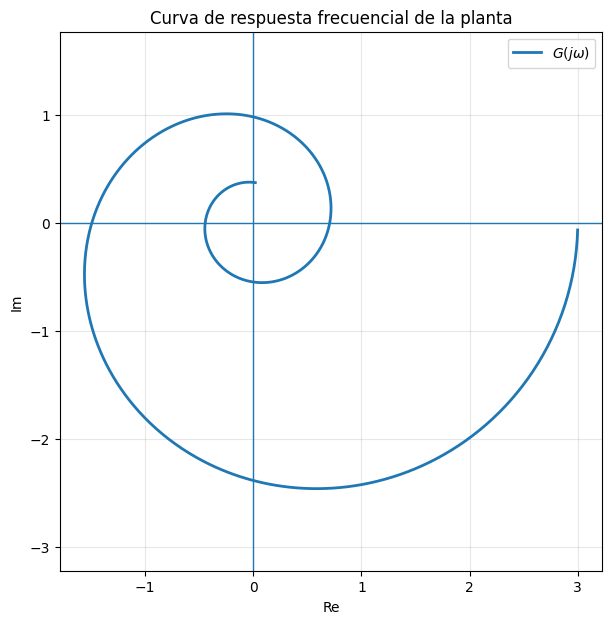

In [5]:
plt.figure(figsize=(7,7))
plt.plot(np.real(Gjw), np.imag(Gjw), linewidth=2, label=r"$G(j\omega)$")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Curva de respuesta frecuencial de la planta")
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis("equal")
plt.show()

/tmp/ipykernel_13388/1959032615.py:4: RuntimeWarning: divide by zero encountered in divide
  "Zona muerta": np.where(Ndead > 1e-12, -1.0/Ndead, np.nan),


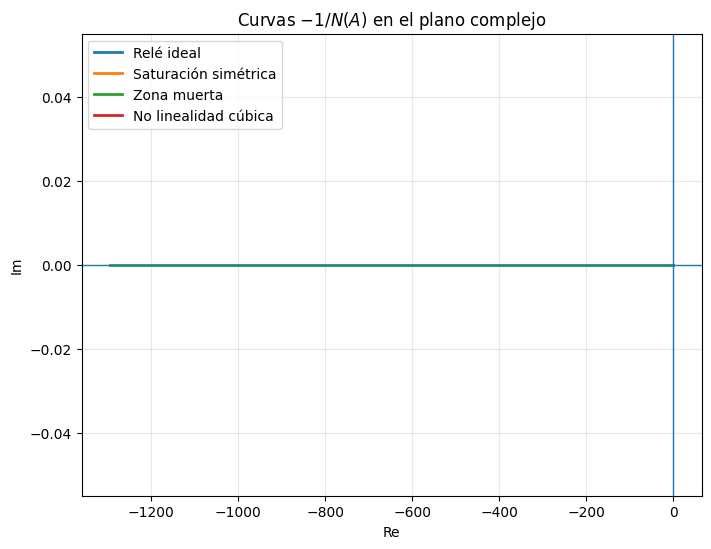

In [6]:
minus_inv_N = {
    "Relé ideal": -1.0/Nrelay,
    "Saturación simétrica": -1.0/Nsat,
    "Zona muerta": np.where(Ndead > 1e-12, -1.0/Ndead, np.nan),
    "No linealidad cúbica": -1.0/Ncubic,
}

plt.figure(figsize=(8,6))
for name, curve in minus_inv_N.items():
    plt.plot(np.real(curve), np.zeros_like(curve), linewidth=2, label=name)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Re")
plt.ylabel("Im")
plt.title(r"Curvas $-1/N(A)$ en el plano complejo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

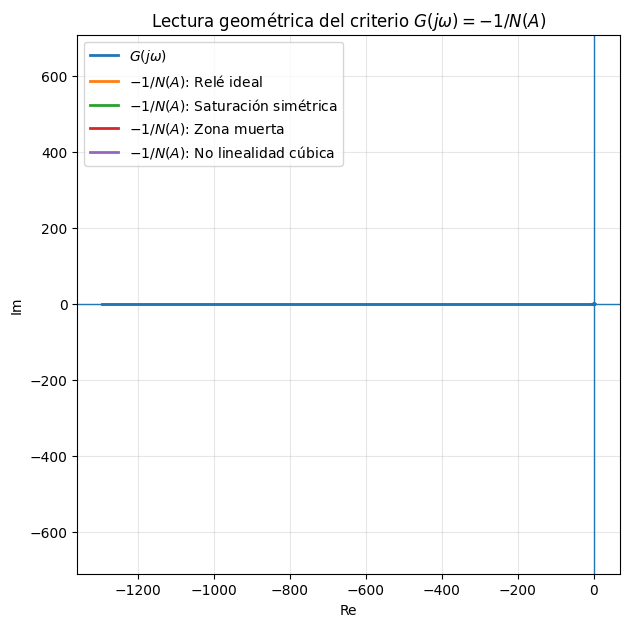

In [7]:
plt.figure(figsize=(7,7))
plt.plot(np.real(Gjw), np.imag(Gjw), linewidth=2, label=r"$G(j\omega)$")

for name, curve in minus_inv_N.items():
    plt.plot(np.real(curve), np.zeros_like(curve), linewidth=2, label=rf"$-1/N(A)$: {name}")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Re")
plt.ylabel("Im")
plt.title(r"Lectura geométrica del criterio $G(j\omega)=-1/N(A)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis("equal")
plt.show()

In [8]:
phase = np.unwrap(np.angle(Gjw))
target = -np.pi
idx = np.argmin(np.abs(phase - target))
w_star = wvals[idx]
G_star = Gjw[idx]

print(f"Frecuencia candidata ω* ≈ {w_star:.4f}")
print(f"G(jω*) = {G_star.real:.6f} {G_star.imag:+.6f}j")

Frecuencia candidata ω* ≈ 1.7426
G(jω*) = -1.493167 -0.000948j


In [9]:
Gmag = np.abs(G_star)

def find_amplitude_for_target(Avals, Nvals, target=1.0/Gmag):
    idx = np.argmin(np.abs(Nvals - target))
    return Avals[idx], Nvals[idx]

print(f"Objetivo de magnitud para N(A): {1.0/Gmag:.6f}\n")

for name, Nvals in [
    ("Relé ideal", Nrelay),
    ("Saturación simétrica", Nsat),
    ("Zona muerta", Ndead),
    ("No linealidad cúbica", Ncubic),
]:
    Astar, Nstar = find_amplitude_for_target(Avals, Nvals)
    print(f"{name:24s}  A* ≈ {Astar:.4f}   N(A*) ≈ {Nstar:.6f}")

Objetivo de magnitud para N(A): 0.669717

Relé ideal                A* ≈ 2.8549   N(A*) ≈ 0.668974
Saturación simétrica      A* ≈ 1.7968   N(A*) ≈ 0.670114
Zona muerta               A* ≈ 3.0473   N(A*) ≈ 0.669619
No linealidad cúbica      A* ≈ 0.2000   N(A*) ≈ 1.003600


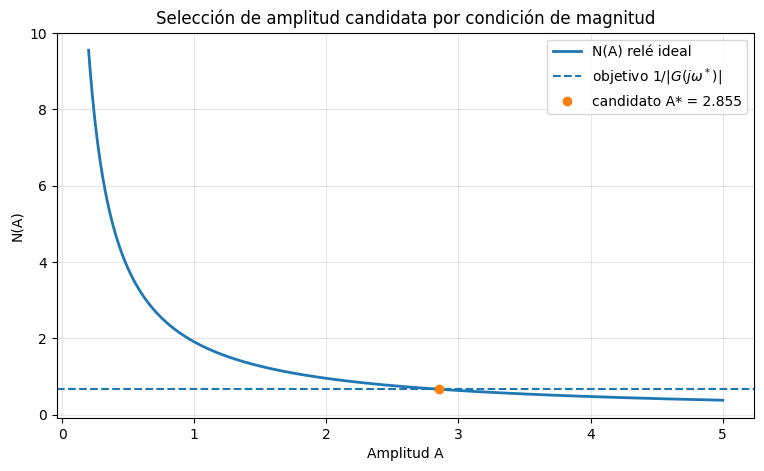

In [11]:
Astar_relay, Nstar_relay = find_amplitude_for_target(Avals, Nrelay)

plt.figure(figsize=(9,5))
plt.plot(Avals, Nrelay, linewidth=2, label="N(A) relé ideal")
plt.axhline(1.0/Gmag, linestyle='--', label=r"objetivo $1/|G(j\omega^*)|$")
plt.plot([Astar_relay], [Nstar_relay], 'o', label=rf"candidato A* = {Astar_relay:.3f}")
plt.xlabel("Amplitud A")
plt.ylabel("N(A)")
plt.title("Selección de amplitud candidata por condición de magnitud")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Sugerencias de exploración

1. Cambia los parámetros de la planta `K_g`, `a`, `L` y observa cómo se mueve la curva `G(jω)`.
2. Cambia los parámetros de las no linealidades y observa cómo se desplazan las curvas `N(A)` y `-1/N(A)`.
3. Para la no linealidad cúbica, cambia el signo de `beta` y compara endurecimiento y ablandamiento.
4. Usa otras plantas lineales y verifica cuándo la construcción geométrica ofrece candidatos razonables a ciclo límite.